In [1]:
import wfdb

print("WFDB version:", wfdb.__version__)

WFDB version: 4.3.1


In [2]:
record = wfdb.rdheader(
    "a103l",
    pn_dir="challenge-2015/training"
)

print("Record name:", record.record_name)
print("Sampling frequency:", record.fs)
print("Number of signals:", record.n_sig)
print("Signal names:", record.sig_name)
print("Signal units:", record.units)
print("Signal length:", record.sig_len)

Record name: a103l
Sampling frequency: 250
Number of signals: 3
Signal names: ['II', 'V', 'PLETH']
Signal units: ['mV', 'mV', 'NU']
Signal length: 82500


In [3]:
record = wfdb.rdrecord(
    "a103l",
    pn_dir="challenge-2015/training"
)

print("Signal shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)

Signal shape: (82500, 3)
Signal names: ['II', 'V', 'PLETH']


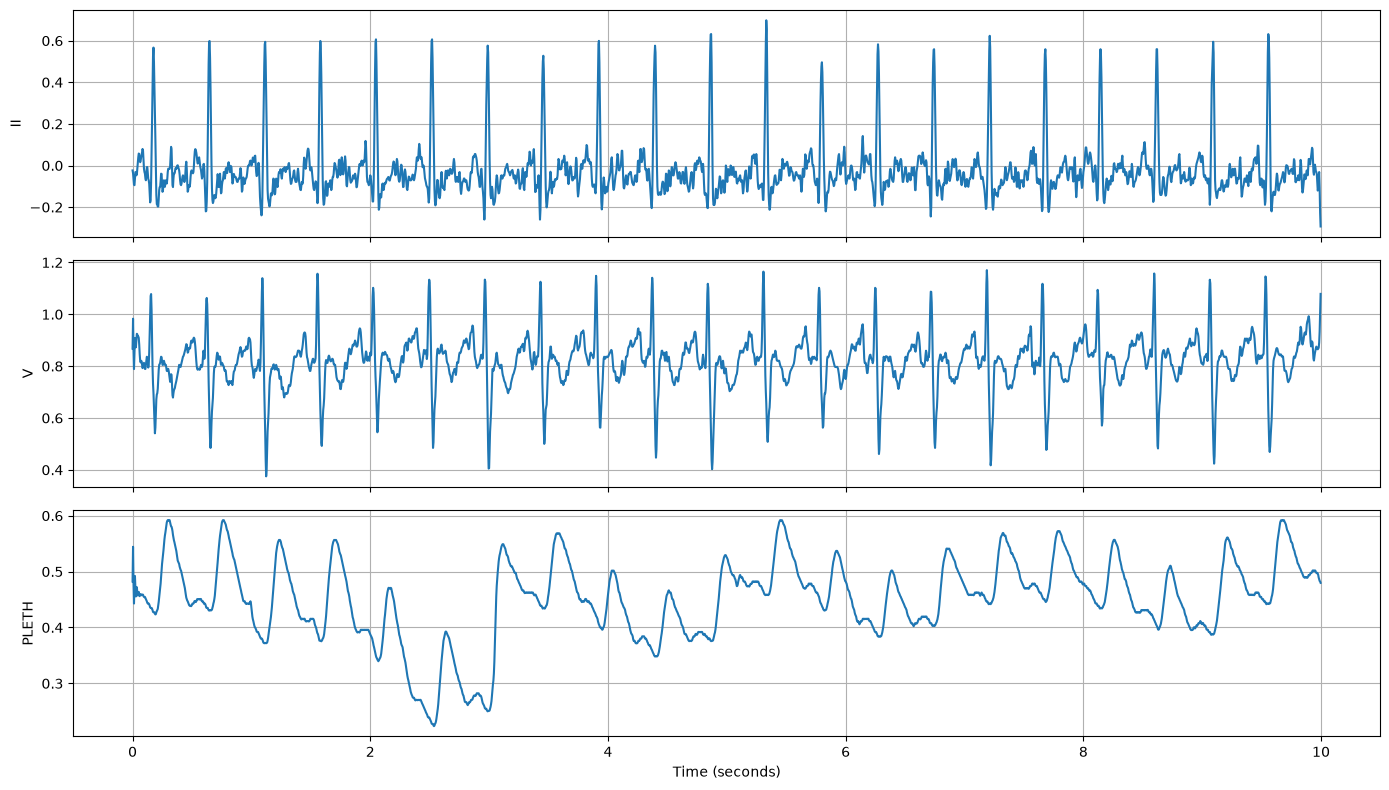

In [4]:
import matplotlib.pyplot as plt

fs = record.fs
duration = 10
samples = int(fs * duration)

time = [i / fs for i in range(samples)]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, signal_name in enumerate(record.sig_name):
    axes[i].plot(time, record.p_signal[:samples, i])
    axes[i].set_ylabel(signal_name)
    axes[i].grid(True)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

In [5]:
comments = record.comments

print("Record comments:")
for comment in comments:
    print(comment)

Record comments:
Asystole
False alarm


In [6]:
header = wfdb.rdheader(
    "a103l",
    pn_dir="challenge-2015/training"
)

print(header.__dict__)

{'record_name': 'a103l', 'n_sig': 3, 'fs': 250, 'counter_freq': None, 'base_counter': None, 'sig_len': 82500, 'base_time': None, 'base_date': None, 'comments': ['Asystole', 'False alarm'], 'sig_name': ['II', 'V', 'PLETH'], 'p_signal': None, 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['a103l.mat', 'a103l.mat', 'a103l.mat'], 'fmt': ['16', '16', '16'], 'samps_per_frame': [1, 1, 1], 'skew': [None, None, None], 'byte_offset': [24, 24, 24], 'adc_gain': [7247.0, 10520.0, 12530.0], 'baseline': [0, 0, 0], 'units': ['mV', 'mV', 'NU'], 'adc_res': [16, 16, 16], 'adc_zero': [0, 0, 0], 'init_value': [-171, 9127, 6042], 'checksum': [-27403, -301, -17391], 'block_size': [0, 0, 0]}


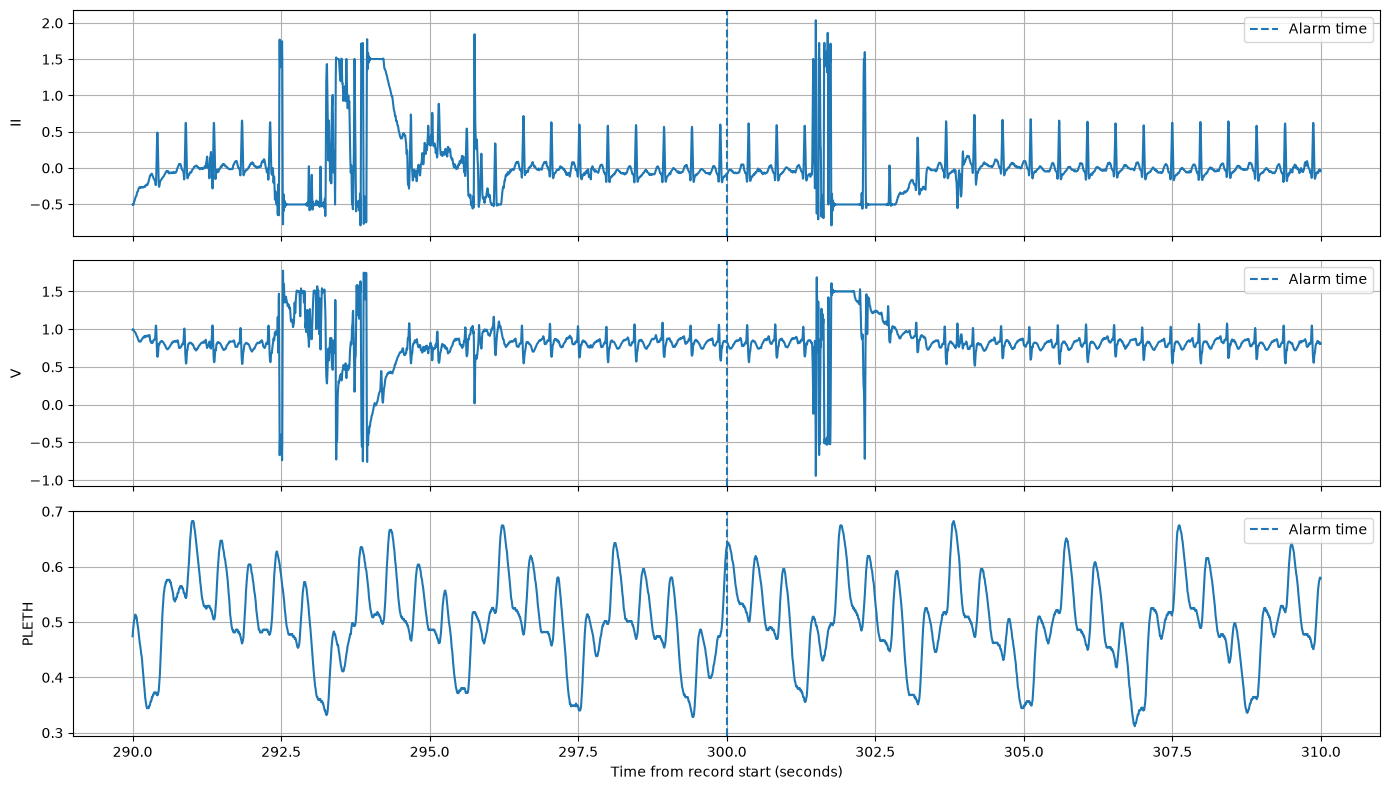

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fs = record.fs

start_time = 290
end_time = 310

start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

time = np.arange(start_sample, end_sample) / fs

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, signal_name in enumerate(record.sig_name):
    axes[i].plot(
        time,
        record.p_signal[start_sample:end_sample, i]
    )
    axes[i].set_ylabel(signal_name)
    axes[i].axvline(300, linestyle="--", label="Alarm time")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Time from record start (seconds)")

plt.tight_layout()
plt.show()

In [8]:
import wfdb

records = wfdb.get_record_list("challenge-2015/training")

print("Number of records:", len(records))
print("First 20 records:")
print(records[:20])

ValueError: The database https://physionet.org/files/challenge-2015/training has no WFDB files to download

In [9]:
import wfdb.processing as processing

fs = record.fs

ecg = record.p_signal[:, 0]  # Lead II

qrs_indices = processing.xqrs_detect(
    sig=ecg,
    fs=fs
)

print("Num" \
"ber of detected QRS complexes:", len(qrs_indices))
print("First 10 QRS sample locations:")
print(qrs_indices[:10])

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Number of detected QRS complexes: 692
First 10 QRS sample locations:
[  44  162  279  395  512  630  747  864  980 1099]


In [10]:
import numpy as np

qrs_times = qrs_indices / fs

rr_intervals = np.diff(qrs_times)
heart_rates = 60 / rr_intervals

print("First 10 QRS times (seconds):")
print(qrs_times[:10])

print("\nFirst 10 RR intervals (seconds):")
print(rr_intervals[:10])

print("\nFirst 10 derived heart rates (bpm):")
print(heart_rates[:10])

First 10 QRS times (seconds):
[0.176 0.648 1.116 1.58  2.048 2.52  2.988 3.456 3.92  4.396]

First 10 RR intervals (seconds):
[0.472 0.468 0.464 0.468 0.472 0.468 0.468 0.464 0.476 0.468]

First 10 derived heart rates (bpm):
[127.11864407 128.20512821 129.31034483 128.20512821 127.11864407
 128.20512821 128.20512821 129.31034483 126.05042017 128.20512821]


In [11]:
# Select detected QRS complexes around the alarm region
mask = (qrs_times >= 290) & (qrs_times <= 310)
alarm_qrs_times = qrs_times[mask]

# Calculate RR intervals and HR within this region
alarm_rr = np.diff(alarm_qrs_times)
alarm_hr = 60 / alarm_rr

print("QRS times around alarm:")
print(alarm_qrs_times)

print("\nRR intervals around alarm:")
print(alarm_rr)

print("\nDerived HR around alarm:")
print(alarm_hr)

QRS times around alarm:
[290.416 290.896 291.372 291.84  292.312 293.272 293.736 294.684 295.624
 296.104 296.58  297.048 298.    298.472 298.944 299.416 299.892 300.368
 300.84  301.312 301.564 302.316 303.212 304.168 304.644 305.116 305.596
 306.072 306.544 307.02  307.5   307.972 308.444 308.92  309.4   309.872]

RR intervals around alarm:
[0.48  0.476 0.468 0.472 0.96  0.464 0.948 0.94  0.48  0.476 0.468 0.952
 0.472 0.472 0.472 0.476 0.476 0.472 0.472 0.252 0.752 0.896 0.956 0.476
 0.472 0.48  0.476 0.472 0.476 0.48  0.472 0.472 0.476 0.48  0.472]

Derived HR around alarm:
[125.         126.05042017 128.20512821 127.11864407  62.5
 129.31034483  63.29113924  63.82978723 125.         126.05042017
 128.20512821  63.02521008 127.11864407 127.11864407 127.11864407
 126.05042017 126.05042017 127.11864407 127.11864407 238.0952381
  79.78723404  66.96428571  62.76150628 126.05042017 127.11864407
 125.         126.05042017 127.11864407 126.05042017 125.
 127.11864407 127.11864407 126.0504

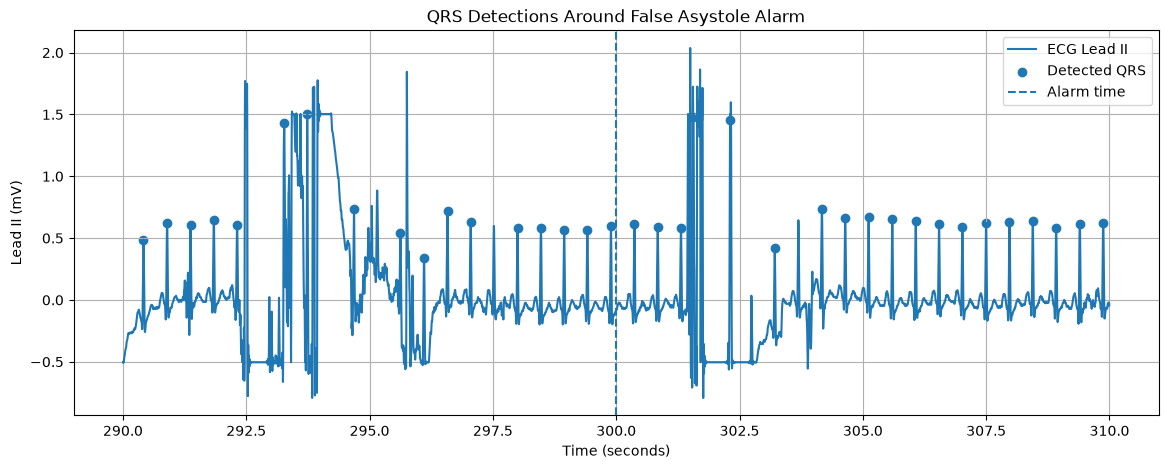

In [12]:
start_time = 290
end_time = 310

start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

plt.figure(figsize=(14, 5))

plt.plot(
    np.arange(start_sample, end_sample) / fs,
    record.p_signal[start_sample:end_sample, 0],
    label="ECG Lead II"
)

region_qrs = qrs_indices[
    (qrs_indices >= start_sample) &
    (qrs_indices <= end_sample)
]

plt.scatter(
    region_qrs / fs,
    record.p_signal[region_qrs, 0],
    label="Detected QRS"
)

plt.axvline(300, linestyle="--", label="Alarm time")

plt.xlabel("Time (seconds)")
plt.ylabel("Lead II (mV)")
plt.title("QRS Detections Around False Asystole Alarm")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from scipy.signal import find_peaks

pleth = record.p_signal[:, 2]

# Simple exploratory peak detection
pleth_peaks, properties = find_peaks(
    pleth,
    distance=int(0.3 * fs),
    prominence=0.03
)

pleth_peak_times = pleth_peaks / fs

print("Number of detected PLETH peaks:", len(pleth_peaks))
print("First 10 PLETH peak times:")
print(pleth_peak_times[:10])

Number of detected PLETH peaks: 666
First 10 PLETH peak times:
[4.000e-03 3.080e-01 7.640e-01 1.240e+00 1.712e+00 2.156e+00 2.636e+00
 3.116e+00 3.568e+00 4.048e+00]


In [14]:
pulse_intervals = np.diff(pleth_peak_times)
pulse_rates = 60 / pulse_intervals

print("First 10 pulse intervals:")
print(pulse_intervals[:10])

print("\nFirst 10 derived pulse rates:")
print(pulse_rates[:10])

First 10 pulse intervals:
[0.304 0.456 0.476 0.472 0.444 0.48  0.48  0.452 0.48  0.464]

First 10 derived pulse rates:
[197.36842105 131.57894737 126.05042017 127.11864407 135.13513514
 125.         125.         132.74336283 125.         129.31034483]


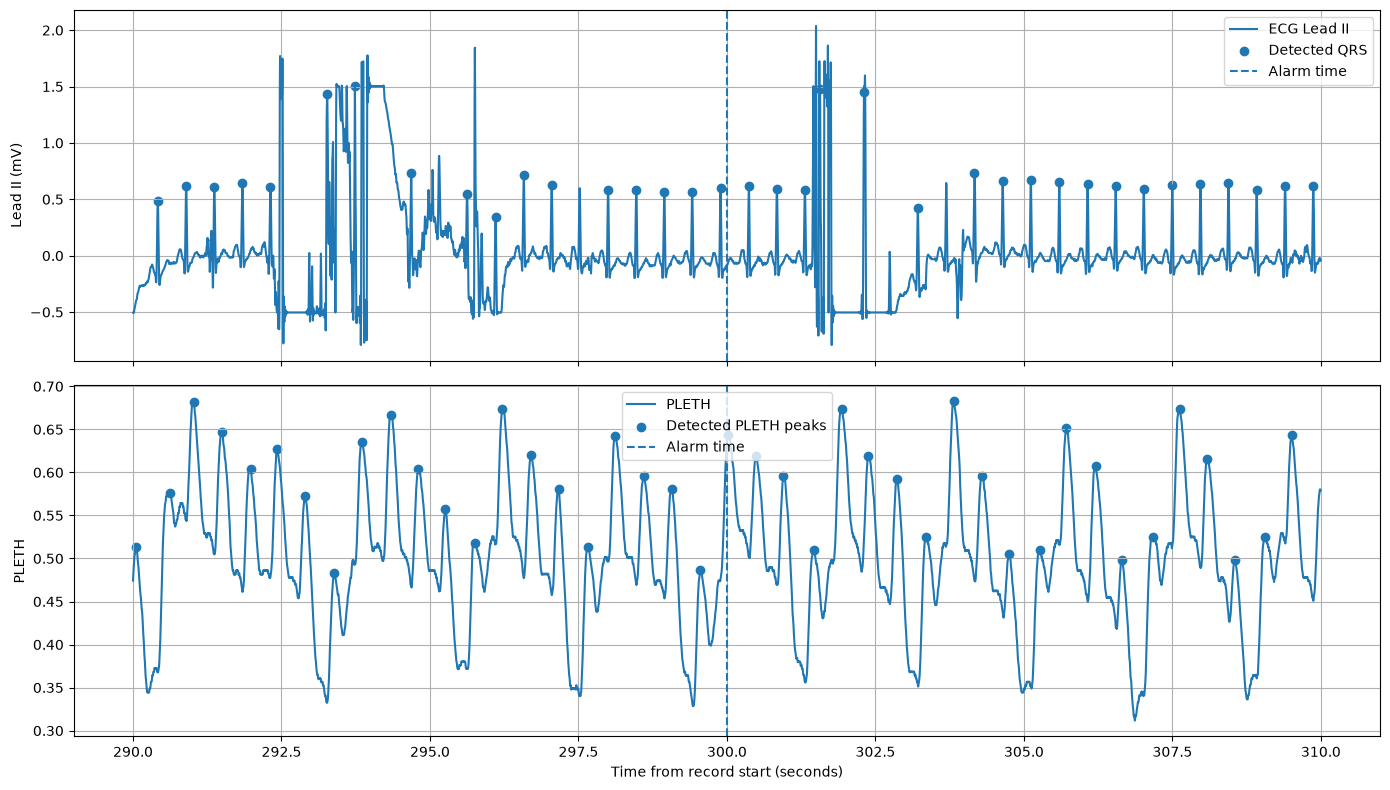

In [15]:
start_time = 290
end_time = 310

start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

# QRS detections in window
region_qrs = qrs_indices[
    (qrs_indices >= start_sample) &
    (qrs_indices <= end_sample)
]

# PLETH peak detections in window
region_pleth_peaks = pleth_peaks[
    (pleth_peaks >= start_sample) &
    (pleth_peaks <= end_sample)
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ECG
axes[0].plot(
    np.arange(start_sample, end_sample) / fs,
    record.p_signal[start_sample:end_sample, 0],
    label="ECG Lead II"
)

axes[0].scatter(
    region_qrs / fs,
    record.p_signal[region_qrs, 0],
    label="Detected QRS"
)

axes[0].axvline(300, linestyle="--", label="Alarm time")
axes[0].set_ylabel("Lead II (mV)")
axes[0].legend()
axes[0].grid(True)

# PLETH
axes[1].plot(
    np.arange(start_sample, end_sample) / fs,
    pleth[start_sample:end_sample],
    label="PLETH"
)

axes[1].scatter(
    region_pleth_peaks / fs,
    pleth[region_pleth_peaks],
    label="Detected PLETH peaks"
)

axes[1].axvline(300, linestyle="--", label="Alarm time")
axes[1].set_ylabel("PLETH")
axes[1].set_xlabel("Time from record start (seconds)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Dataset Audit

## Dataset
PhysioNet/CinC Challenge 2015

## Questions to Answer
1. What alarm types are included?
2. What does "True alarm" mean in the reference labels?
3. What does "False alarm" mean?
4. What waveform channels are available across records?
5. Do all records contain ECG and PLETH?
6. Is a numeric SpO2 signal available and suitable for our planned experiment?
7. Which alarm types are relevant to our simplified project?
8. What can this dataset legitimately allow us to evaluate?
9. What can this dataset NOT allow us to claim?

# Dataset Audit — PhysioNet/CinC Challenge 2015

## 1. Dataset Purpose

The PhysioNet/Computing in Cardiology Challenge 2015 focused on reducing false life-threatening arrhythmia alarms in intensive care monitoring data.

The dataset contains retrospective multiparameter bedside-monitor recordings associated with arrhythmia alarm events. The purpose of this project is not to reproduce the original bedside monitors or their proprietary alarm algorithms. Instead, selected records will be used to explore how simplified alarm logic behaves when provided with physiological waveform information of varying quality.

---

## 2. Alarm Types

The Challenge includes five life-threatening arrhythmia alarm categories:

- Asystole
- Extreme Bradycardia
- Extreme Tachycardia
- Ventricular Tachycardia
- Ventricular Fibrillation/Flutter

The exact reference criteria used by the Challenge should be taken from the official PhysioNet Challenge documentation rather than assumed to represent the alarm logic of all commercial patient monitors.

---

## 3. Meaning of a True Alarm

A "True alarm" reference label indicates that the alarm event satisfied the Challenge reference criteria for the corresponding arrhythmia category according to the Challenge's reference annotation/adjudication process.

A True alarm label does not, by itself, describe the patient's complete clinical condition, treatment requirements, or overall level of physiological distress.

---

## 4. Meaning of a False Alarm

A "False alarm" reference label indicates that the triggered alarm did not satisfy the Challenge reference criteria for that arrhythmia category.

Factors such as signal artifact, poor signal quality, sensor or electrode problems, and limitations of automated signal processing can contribute to false alarm behavior in patient monitoring.

However, the label "False alarm" does not by itself identify the specific cause of the false alarm in an individual record. The cause should not be claimed unless supported by the available waveform evidence or reference information.

---

## 5. Available Waveform Information

The Challenge provides multiparameter bedside-monitor waveform recordings. Depending on the record, available signals may include ECG and pulsatile signals such as photoplethysmography (PLETH) and/or arterial blood pressure (ABP).

The exact channels available in each selected record must be checked from that record's WFDB header rather than assumed to be identical across the entire dataset.

For example, record `a103l`, inspected during this project, contains:

- ECG Lead II
- ECG Lead V
- PLETH

All three channels are sampled at 250 Hz in this record.

---

## 6. PLETH and SpO2 Limitation

A PLETH waveform should not be treated as equivalent to a numeric SpO2 measurement.

For this project, PLETH can potentially be used to derive exploratory pulse timing or pulse-rate information when signal quality is adequate.

The project will not implement a numeric SpO2 alarm experiment unless suitable numeric SpO2 data are independently verified to exist in the selected dataset records.

Therefore, the initial cross-parameter comparison considered by this project is:

ECG-derived Heart Rate (HR)
vs.
PLETH-derived Pulse Rate (PR)

rather than:

ECG Heart Rate
vs.
numeric SpO2.

---

## 7. Initial Project Scope Decision

Extreme Bradycardia and Extreme Tachycardia are initial candidates for the simplified rate-based alarm comparison because they are directly relevant to heart-rate behavior.

Asystole may also be useful for selected case-based analysis because loss or failure of beat detection is directly relevant to the project's signal-quality and cross-signal reasoning.

Ventricular Tachycardia and Ventricular Fibrillation/Flutter require additional rhythm and waveform-morphology reasoning and will not automatically be included in the first simplified implementation.

The final alarm categories used in Phase 3 will be selected only after inspecting representative records and confirming that the available signals support the planned comparison.

This is a project scope decision and does not imply that real commercial monitors use the simplified algorithms implemented here.

---

## 8. What the Dataset Can Support in This Project

The dataset can support a retrospective comparison between simplified alarm algorithms using selected Challenge records and their available reference labels.

The project can investigate questions such as:

- How does simple threshold-based alarm logic behave on selected retrospective records?
- How does basic signal-quality screening change algorithm behavior?
- How does requiring an abnormal condition to persist change alarm behavior?
- Can ECG-derived HR and PLETH-derived PR disagreement provide useful contextual information?
- In which examples does the context-aware system behave differently from the baseline?
- What kinds of errors remain after adding simplified contextual logic?

Evaluation may include predefined quantitative performance measures where appropriate, together with detailed inspection of error cases.

---

## 9. What the Dataset and Project Cannot Prove

Results from this project cannot establish:

- Clinical safety.
- Clinical effectiveness.
- Diagnostic accuracy for real-world use.
- Regulatory compliance.
- Suitability for deployment in a patient monitor.
- Superiority to a commercial monitoring system.
- That the simplified algorithms reproduce proprietary commercial alarm logic.
- That fewer generated alarms necessarily result in safer patient care.
- That suspected signal artifact proves an alarm is false.
- That performance on selected retrospective records will generalize to all patients, hospitals, devices, or monitoring environments.

The project is an educational retrospective simulation intended to demonstrate biomedical signal, alarm-management, troubleshooting, and product-thinking concepts.

---

## 10. Preliminary Observation from Record a103l

Record `a103l` contains ECG Lead II, ECG Lead V, and PLETH and is labeled:

Alarm type: Asystole
Reference classification: False alarm

During exploratory analysis, repeating ECG and PLETH activity was visible around the alarm region.

An offline QRS detector produced irregular beat detections during sections of disturbed ECG, resulting in large changes in derived instantaneous heart rate.

At the same time, the PLETH waveform retained visible pulsatile structure during portions of the ECG disturbance.

This example demonstrates why independent physiological signals may provide useful contextual information when interpreting automated parameter estimates.

However, this analysis does not establish the exact mechanism that caused the original bedside monitor alarm, and the offline QRS and PLETH peak detectors used in this notebook are not assumed to reproduce the algorithms used by the original bedside monitor.

# Representative Record Inspection

In [18]:
import wfdb

def inspect_record(record_name):
    try:
        header = wfdb.rdheader(
            record_name,
            pn_dir="challenge-2015/training"
        )

        alarm_type = (
            header.comments[0]
            if len(header.comments) > 0
            else "Unknown"
        )

        reference_label = (
            header.comments[1]
            if len(header.comments) > 1
            else "Unknown"
        )

        return {
            "Record": record_name,
            "Alarm Type": alarm_type,
            "Reference Label": reference_label,
            "Channels": header.sig_name,
            "Sampling Frequency": header.fs,
            "Duration (s)": header.sig_len / header.fs,
        }

    except Exception as e:
        return {
            "Record": record_name,
            "Error": str(e)
        }

In [17]:
result = inspect_record("a103l")
result

{'Record': 'a103l',
 'Alarm Type': 'Asystole',
 'Reference Label': 'False alarm',
 'Channels': ['II', 'V', 'PLETH'],
 'Sampling Frequency': 250,
 'Duration (s)': 330.0}

## Representative Case 1 — a103l

**Alarm type:** Asystole  
**Reference label:** False alarm  
**Available signals:** ECG Lead II, ECG Lead V, PLETH  
**Sampling frequency:** 250 Hz  
**Duration:** 330 seconds  

### Observations

The record contains two ECG signals and one PLETH waveform.

Visual inspection around the alarm region showed continuing physiological waveform activity. Portions of the ECG became significantly disturbed, while the PLETH retained visible pulsatile structure during parts of the disturbance.

An exploratory XQRS detector produced irregular QRS detections during disturbed portions of the ECG. These detections resulted in abnormal instantaneous HR estimates, including values substantially different from the approximately 125–129 bpm estimates seen during more regular portions of the record.

A simple exploratory PLETH peak detector was also able to identify candidate pulse peaks. The PLETH provided an independent source of information that could potentially provide context when ECG-derived measurements became unreliable.

### Interpretation

This case demonstrates the motivation for combining signal-quality information and cross-signal context rather than relying exclusively on a single derived parameter.

However, this analysis does not establish the exact cause of the original false alarm. The offline XQRS and PLETH peak-detection algorithms used here are exploratory and are not the algorithms used by the original bedside monitor.

HR–PR disagreement or the presence of a PLETH waveform alone should not automatically classify an alarm as false.

In [20]:
candidate_records = [
    "a104s",
    "a105l",
    "a109l",
    "a123l",
    "a134s",
    "a142s",
    "a145l",
    "a152s",
    "a161l",
    "a163l",
    "a165l",
    "a167l",
    "a170s",
    "a171l",
]

results = [inspect_record(record_id) for record_id in candidate_records]

import pandas as pd

inspection_df = pd.DataFrame(results)

inspection_df

,Record,Alarm Type,Reference Label,Channels,Sampling Frequency,Duration (s)
0,a104s,Asystole,False alarm,"[II, V, PLETH]",250,300.0
1,a105l,Asystole,False alarm,"[II, V, PLETH]",250,330.0
2,a109l,Asystole,False alarm,"[II, aVF, ABP, RESP]",250,330.0
3,a123l,Asystole,False alarm,"[II, V, PLETH, ABP]",250,330.0
4,a134s,Asystole,False alarm,"[II, V, PLETH, ABP]",250,300.0
5,a142s,Asystole,True alarm,"[II, V, PLETH, ABP]",250,300.0
6,a145l,Asystole,False alarm,"[II, V, PLETH, RESP]",250,330.0
7,a152s,Asystole,False alarm,"[II, V, PLETH, RESP]",250,300.0
8,a161l,Asystole,True alarm,"[II, V, PLETH, RESP]",250,330.0
9,a163l,Asystole,False alarm,"[II, V, PLETH, RESP]",250,330.0


In [21]:
record_a142s = wfdb.rdrecord(
    "a142s",
    pn_dir="challenge-2015/training"
)

print("Record:", record_a142s.record_name)
print("Comments:", record_a142s.comments)
print("Signals:", record_a142s.sig_name)
print("Sampling frequency:", record_a142s.fs)
print("Duration:", record_a142s.sig_len / record_a142s.fs, "seconds")

Record: a142s
Comments: ['Asystole', 'True alarm']
Signals: ['II', 'V', 'PLETH', 'ABP']
Sampling frequency: 250
Duration: 300.0 seconds


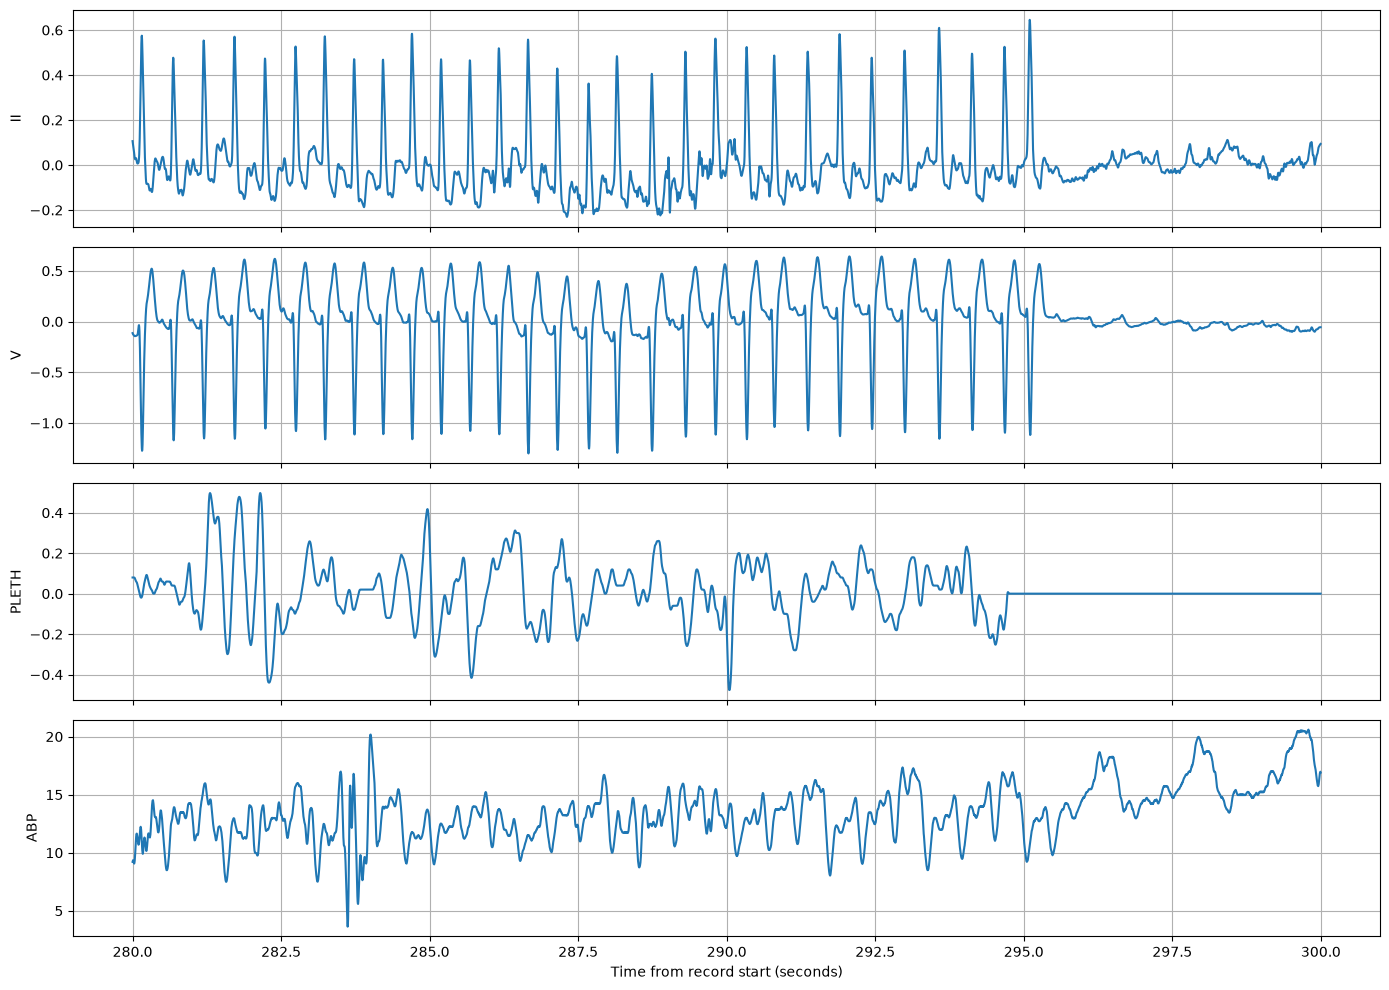

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fs = record_a142s.fs

start_time = 280
end_time = 300

start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

time = np.arange(start_sample, end_sample) / fs

fig, axes = plt.subplots(
    len(record_a142s.sig_name),
    1,
    figsize=(14, 10),
    sharex=True
)

for i, signal_name in enumerate(record_a142s.sig_name):
    axes[i].plot(
        time,
        record_a142s.p_signal[start_sample:end_sample, i]
    )
    axes[i].set_ylabel(signal_name)
    axes[i].grid(True)

axes[-1].set_xlabel("Time from record start (seconds)")

plt.tight_layout()
plt.show()

## Representative Case 2 — a142s

**Alarm type:** Asystole  
**Reference label:** True alarm  
**Available signals:** ECG Lead II, ECG Lead V, PLETH, ABP  
**Sampling frequency:** 250 Hz  
**Duration:** 300 seconds  

### Observations

Near the end of the record, both ECG channels show a substantial change from their earlier repeating waveform patterns.

The PLETH channel becomes flat at approximately 295 seconds in the displayed data.

The ABP channel does not show an obvious simultaneous flatline in this visualization and continues to contain variation.

### Interpretation

This record demonstrates that multiparameter alarm interpretation is not necessarily as simple as requiring every available channel to show the same visual behavior.

The record is classified as a True Asystole alarm according to the Challenge reference label. The apparent disagreement between available signals requires cautious interpretation and should not be used to override the reference classification without further evidence.

This case also demonstrates an important limitation of a simplified cross-parameter algorithm: the presence of activity or variation in another channel does not automatically prove that an ECG-based alarm is false.

The project should therefore treat cross-signal consistency as contextual information rather than absolute ground truth.

In [23]:
import requests

records_url = "https://physionet.org/files/challenge-2015/1.0.0/training/RECORDS"

response = requests.get(records_url)
response.raise_for_status()

all_records = response.text.strip().splitlines()

print("Number of records found:", len(all_records))
print("First 20 record names:")
print(all_records[:20])

Number of records found: 750
First 20 record names:
['v100s', 'v101l', 'v102s', 'a103l', 'a104s', 'a105l', 't106s', 't107l', 't108s', 'a109l', 't110s', 'v111l', 't112s', 'v113l', 't114s', 'v115l', 't116s', 't117l', 't118s', 'v119l']


In [24]:
# Inspect records until we find useful examples of
# Extreme Bradycardia and Extreme Tachycardia

target_records = []

for i, record_name in enumerate(all_records):
    result = inspect_record(record_name)

    alarm_type = result.get("Alarm Type", "")
    reference_label = result.get("Reference Label", "")
    channels = result.get("Channels", [])

    if (
        alarm_type in ["Extreme Bradycardia", "Extreme Tachycardia"]
        and "PLETH" in channels
    ):
        target_records.append(result)

    # Stop once we have enough candidates
    if len(target_records) >= 20:
        break

print("Found:", len(target_records), "candidate records")

target_df = pd.DataFrame(target_records)

target_df[
    [
        "Record",
        "Alarm Type",
        "Reference Label",
        "Channels",
        "Duration (s)"
    ]
]

Found: 0 candidate records


KeyError: "None of [Index(['Record', 'Alarm Type', 'Reference Label', 'Channels', 'Duration (s)'], dtype='str')] are in the [columns]"

In [25]:
test_records = [
    "v100s",
    "v101l",
    "v102s",
    "t106s",
    "t107l",
    "t108s",
    "t110s",
]

for record_name in test_records:
    result = inspect_record(record_name)
    print(
        record_name,
        "| Alarm:", result.get("Alarm Type"),
        "| Label:", result.get("Reference Label"),
        "| Channels:", result.get("Channels")
    )

v100s | Alarm: Ventricular_Tachycardia | Label: False alarm | Channels: ['II', 'V', 'PLETH', 'RESP']
v101l | Alarm: Ventricular_Tachycardia | Label: False alarm | Channels: ['II', 'V', 'PLETH', 'RESP']
v102s | Alarm: Ventricular_Tachycardia | Label: False alarm | Channels: ['II', 'V', 'PLETH', 'RESP']
t106s | Alarm: Tachycardia | Label: True alarm | Channels: ['II', 'III', 'PLETH']
t107l | Alarm: Tachycardia | Label: True alarm | Channels: ['II', 'III', 'PLETH']
t108s | Alarm: Tachycardia | Label: True alarm | Channels: ['II', 'III', 'PLETH']
t110s | Alarm: Tachycardia | Label: True alarm | Channels: ['II', 'V', 'ABP']


In [26]:
false_tachy_candidates = []

for record_name in all_records:
    if not record_name.startswith("t"):
        continue

    result = inspect_record(record_name)

    if (
        result.get("Alarm Type") == "Tachycardia"
        and result.get("Reference Label") == "False alarm"
        and "PLETH" in result.get("Channels", [])
    ):
        false_tachy_candidates.append(result)

        if len(false_tachy_candidates) >= 3:
            break

for result in false_tachy_candidates:
    print(
        result["Record"],
        "|", result["Alarm Type"],
        "|", result["Reference Label"],
        "|", result["Channels"]
    )

t409l | Tachycardia | False alarm | ['II', 'V', 'PLETH', 'ABP']
t469l | Tachycardia | False alarm | ['II', 'V', 'PLETH']
t503l | Tachycardia | False alarm | ['II', 'V', 'PLETH', 'RESP']
